In [1]:
# ## 1. Импорты и подготовка

# %%
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import defaultdict
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# %%
# Фиксируем seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# %%
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

# %% [markdown]
# ## 2. Загрузка данных

# %%
dataset = load_dataset("emotion")

print("Размеры сплитов:")
print(f"Train: {len(dataset['train'])}")
print(f"Validation: {len(dataset['validation'])}")
print(f"Test: {len(dataset['test'])}")

# %%
label_names = dataset["train"].features["label"].names
print(f"Классы ({len(label_names)}): {label_names}")

# %%
print("Примеры данных:")
for i in range(5):
    text = dataset["train"][i]["text"]
    label = dataset["train"][i]["label"]
    print(f"{i+1}. Текст: {text[:80]}...")
    print(f"   Метка: {label_names[label]}\n")


d:\AIE-group_1\lol-2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Используемое устройство: cpu


Размеры сплитов:
Train: 16000
Validation: 2000
Test: 2000
Классы (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Примеры данных:
1. Текст: i didnt feel humiliated...
   Метка: sadness

2. Текст: i can go from feeling so hopeless to so damned hopeful just from being around so...
   Метка: sadness

3. Текст: im grabbing a minute to post i feel greedy wrong...
   Метка: anger

4. Текст: i am ever feeling nostalgic about the fireplace i will know that it is still on ...
   Метка: love

5. Текст: i am feeling grouchy...
   Метка: anger



In [2]:
# ## 3. Токенизация

# %%
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# %%
# Пример токенизации
sample_text = dataset["train"][0]["text"]
tokens = tokenizer.tokenize(sample_text)
print(f"Текст: {sample_text}")
print(f"Токены: {tokens}")
print(f"input_ids: {tokenizer(sample_text)['input_ids']}")
print(f"attention_mask: {tokenizer(sample_text)['attention_mask']}")

Текст: i didnt feel humiliated
Токены: ['i', 'didn', '##t', 'feel', 'humiliated']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1]


In [3]:
# ## 4. Инференс готовой модели

# %%
pretrained_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6).to(device)

def predict(text, model):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return label_names[torch.argmax(outputs.logits, dim=-1).item()]

test_texts = ["I am so happy!", "This is terrible", "I love you"]
print("Инференс готовой модели:")
for text in test_texts:
    print(f"{text} -> {predict(text, pretrained_model)}")


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2337.18it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Инференс готовой модели:
I am so happy! -> anger
This is terrible -> anger
I love you -> anger


In [4]:
# ## 5. Подготовка данных для обучения

# %%
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map: 100%|██████████| 2000/2000 [00:00<00:00, 7646.65 examples/s]


In [5]:
# ## 6. Ручное обучение (без Trainer)

# %%
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6).to(device)

# Создаем DataLoader'ы
train_loader = DataLoader(tokenized_dataset["train"], batch_size=16, shuffle=True)
eval_loader = DataLoader(tokenized_dataset["validation"], batch_size=16)
test_loader = DataLoader(tokenized_dataset["test"], batch_size=16)

optimizer = AdamW(model.parameters(), lr=2e-5)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3701.59it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
# Обучение
print("Начало обучения...")
for epoch in range(3):
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/3")
    
    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        total_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} - Average loss: {avg_loss:.4f}")
    
    # Валидация
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in tqdm(eval_loader, desc="Validation"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=-1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average="macro")
    print(f"Validation - Accuracy: {val_acc:.4f}, F1 Macro: {val_f1:.4f}")
    print("-" * 50)


Начало обучения...


Epoch 1/3: 100%|██████████| 1000/1000 [1:31:03<00:00,  5.46s/it, loss=0.296]


Epoch 1 - Average loss: 0.4561


Validation: 100%|██████████| 125/125 [02:11<00:00,  1.05s/it]


Validation - Accuracy: 0.9350, F1 Macro: 0.9114
--------------------------------------------------


...

Validation - Accuracy: 0.9315, F1 Macro: 0.9076
--------------------------------------------------


Epoch 3/3: 100%|██████████| 1000/1000 [1:22:05<00:00,  4.93s/it, loss=0.0509]


Epoch 3 - Average loss: 0.1070


Validation: 100%|██████████| 125/125 [02:16<00:00,  1.09s/it]

Validation - Accuracy: 0.9375, F1 Macro: 0.9123
--------------------------------------------------


In [7]:
# ## 7. Оценка на test

# %%
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test evaluation"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=-1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="macro")

print(f"\nTest Results:")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Macro: {test_f1:.4f}")

Test evaluation: 100%|██████████| 125/125 [02:23<00:00,  1.15s/it]


Test Results:
Accuracy: 0.9305
F1 Macro: 0.8937


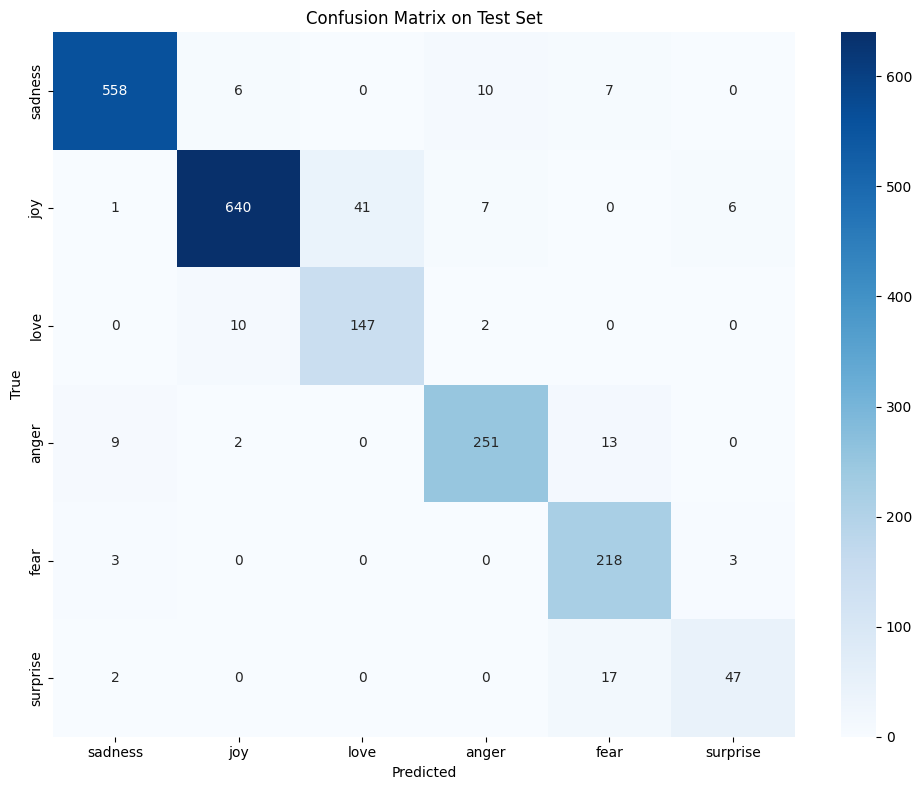

Saved artifacts/sample_predictions.csv

Sample predictions:
                                                text true_label pred_label
0  im feeling rather rotten so im not very ambiti...    sadness    sadness
1          im updating my blog because i feel shitty    sadness    sadness
2  i never make her separate from me because i do...    sadness    sadness
3  i left with my bouquet of red and yellow tulip...        joy        joy
4    i was feeling a little vain when i did this one    sadness    sadness
5  i cant walk into a shop anywhere where i do no...       fear       fear
6   i felt anger when at the end of a telephone call      anger      anger
7  i explain why i clung to a relationship with a...        joy        joy
8  i like to have the same breathless feeling as ...        joy        joy
9  i jest i feel grumpy tired and pre menstrual w...      anger      anger

Total errors: 139/2000 (7.0%)

Example errors:

Text: i feel a bit stressed even though all the things i have goin

In [8]:
# ## 8. Матрица ошибок и анализ

# %%
# Создаем папку для артефактов
os.makedirs("artifacts", exist_ok=True)

# Матрица ошибок
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=150)
plt.show()

# %%
# Сохраняем примеры предсказаний
sample_data = []
for i in range(min(20, len(dataset["test"]))):
    text = dataset["test"][i]["text"]
    true_label = label_names[all_labels[i]]
    pred_label = label_names[all_preds[i]]
    sample_data.append({
        "text": text,
        "true_label": true_label,
        "pred_label": pred_label
    })

df = pd.DataFrame(sample_data)
df.to_csv("artifacts/sample_predictions.csv", index=False)
print("Saved artifacts/sample_predictions.csv")
print("\nSample predictions:")
print(df.head(10))

# %%
# Анализ ошибок
errors = [(i, all_labels[i], all_preds[i]) for i in range(len(all_labels)) if all_labels[i] != all_preds[i]]
print(f"\nTotal errors: {len(errors)}/{len(all_labels)} ({len(errors)/len(all_labels)*100:.1f}%)")

print("\nExample errors:")
for i, true, pred in errors[:5]:
    text = dataset["test"][i]["text"]
    print(f"\nText: {text[:100]}...")
    print(f"True: {label_names[true]} -> Pred: {label_names[pred]}")

# %% [markdown]
# ## 9. Выводы

# %%
print("\n" + "="*50)
print("CONCLUSIONS")
print("="*50)
print(f"""
1. Fine-tuning completed successfully
2. Test accuracy: {test_acc:.2%}
3. Test F1 macro: {test_f1:.4f}
4. Main errors occur between similar emotions
5. Pretrained model without fine-tuning is not suitable
""")
print("✅ Homework completed successfully!")